# Cuaderno 14 adaptado

## Evaluación responsable de un prototipo multimodal para patrones textiles andinos generados

Este cuaderno adapta la estructura experimental del Cuaderno 14 del curso MCC225. El objetivo es evaluar una tarea de recuperación imagen texto usando imágenes generadas y descripciones textuales controladas.

La evaluación se limita a un escenario académico controlado. Los resultados no deben interpretarse como reconocimiento confiable ni clasificación real de objetos culturales.

In [1]:
# ============================================================
# 1. Imports y configuración general
# ============================================================

from pathlib import Path
import random
import json

import numpy as np
import pandas as pd
from PIL import Image

import torch
import open_clip

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SEED = 225
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

BASE_DIR = Path("..").resolve()
DATA_DIR = BASE_DIR / "data"
IMAGE_DIR = DATA_DIR / "images"
RESULTS_DIR = BASE_DIR / "results"
FIGURES_DIR = BASE_DIR / "figures"

MANIFEST_PATH = DATA_DIR / "manifest_textiles_generados.csv"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Dispositivo:", DEVICE)
print("Directorio base:", BASE_DIR)
print("Manifiesto:", MANIFEST_PATH)

d:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-albef-textiles-andinos\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dispositivo: cpu
Directorio base: D:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-textiles-generados-evaluacion-multimodal
Manifiesto: D:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-textiles-generados-evaluacion-multimodal\data\manifest_textiles_generados.csv


In [2]:
# ============================================================
# 2. Carga del manifiesto
# ============================================================

manifest = pd.read_csv(MANIFEST_PATH)

print("Filas:", len(manifest))
print("Columnas:", list(manifest.columns))

manifest.head()

Filas: 40
Columnas: ['image_id', 'image_path', 'caption_1', 'caption_2', 'caption_3', 'caption_4', 'caption_5', 'paleta', 'composicion', 'motivo', 'simetria', 'nivel_ambiguedad', 'observacion']


,image_id,image_path,caption_1,caption_2,caption_3,caption_4,caption_5,paleta,composicion,motivo,simetria,nivel_ambiguedad,observacion
0,T001,data/images/T001.png,Patron textil generado con composicion horizon...,Imagen generada de inspiracion textil con band...,"Diseno geometrico generado con paleta rojo, ne...",Patron sintetico con elementos de bandas geome...,Imagen de patron ornamental generado con rasgo...,rojo_negro_crema,horizontal,bandas geometricas,repetitiva,bajo,Imagen generada por script para evaluacion aca...
1,T002,data/images/T002.png,Patron textil generado con composicion vertica...,Imagen generada de inspiracion textil con band...,"Diseno geometrico generado con paleta azul, cr...",Patron sintetico con elementos de bandas geome...,Imagen de patron ornamental generado con rasgo...,azul_crema_marron,vertical,bandas geometricas,repetitiva,bajo,Imagen generada por script para evaluacion aca...
2,T003,data/images/T003.png,Patron textil generado con composicion central...,Imagen generada de inspiracion textil con romb...,"Diseno geometrico generado con paleta ocre, ma...","Patron sintetico con elementos de rombos, dist...",Imagen de patron ornamental generado con rasgo...,ocre_marron_negro,central,rombos,bilateral,medio,Imagen generada por script para evaluacion aca...
3,T004,data/images/T004.png,Patron textil generado con composicion modular...,Imagen generada de inspiracion textil con grec...,"Diseno geometrico generado con paleta blanco, ...",Patron sintetico con elementos de grecas escal...,Imagen de patron ornamental generado con rasgo...,blanco_negro_gris,modular,grecas escalonadas,repetitiva,medio,Imagen generada por script para evaluacion aca...
4,T005,data/images/T005.png,Patron textil generado con composicion reticul...,Imagen generada de inspiracion textil con cuad...,Diseno geometrico generado con paleta multicol...,Patron sintetico con elementos de cuadricula g...,Imagen de patron ornamental generado con rasgo...,multicolor_tierra,reticular,cuadricula geometrica,repetitiva,bajo,Imagen generada por script para evaluacion aca...


In [3]:
# ============================================================
# 3. Validación básica del dataset
# ============================================================

required_columns = [
    "image_id",
    "image_path",
    "caption_1",
    "caption_2",
    "caption_3",
    "caption_4",
    "caption_5",
    "paleta",
    "composicion",
    "motivo",
    "simetria",
    "nivel_ambiguedad",
    "observacion"
]

missing_columns = [col for col in required_columns if col not in manifest.columns]

if missing_columns:
    raise ValueError(f"Faltan columnas en el manifiesto: {missing_columns}")

missing_images = []

for _, row in manifest.iterrows():
    image_path = BASE_DIR / row["image_path"]
    if not image_path.exists():
        missing_images.append(str(image_path))

print("Imágenes esperadas:", len(manifest))
print("Imágenes faltantes:", len(missing_images))

if missing_images:
    print("Primeras imágenes faltantes:")
    for path in missing_images[:5]:
        print(path)
else:
    print("Todas las imágenes existen.")

Imágenes esperadas: 40
Imágenes faltantes: 0
Todas las imágenes existen.


In [4]:
# ============================================================
# 4. Construcción de textos candidatos
# ============================================================

caption_columns = ["caption_1", "caption_2", "caption_3", "caption_4", "caption_5"]

text_rows = []

for _, row in manifest.iterrows():
    for caption_col in caption_columns:
        text_rows.append({
            "text_id": f"{row['image_id']}_{caption_col}",
            "image_id": row["image_id"],
            "caption_col": caption_col,
            "text": row[caption_col]
        })

texts_df = pd.DataFrame(text_rows)

print("Número de imágenes:", manifest["image_id"].nunique())
print("Número de textos candidatos:", len(texts_df))

texts_df.head()

Número de imágenes: 40
Número de textos candidatos: 200


,text_id,image_id,caption_col,text
0,T001_caption_1,T001,caption_1,Patron textil generado con composicion horizon...
1,T001_caption_2,T001,caption_2,Imagen generada de inspiracion textil con band...
2,T001_caption_3,T001,caption_3,"Diseno geometrico generado con paleta rojo, ne..."
3,T001_caption_4,T001,caption_4,Patron sintetico con elementos de bandas geome...
4,T001_caption_5,T001,caption_5,Imagen de patron ornamental generado con rasgo...


In [5]:
# ============================================================
# 5. Carga del modelo OpenCLIP
# ============================================================

MODEL_NAME = "ViT-B-32"
PRETRAINED = "laion2b_s34b_b79k"

model, _, preprocess = open_clip.create_model_and_transforms(
    MODEL_NAME,
    pretrained=PRETRAINED
)

tokenizer = open_clip.get_tokenizer(MODEL_NAME)

model = model.to(DEVICE)
model.eval()

print("Modelo:", MODEL_NAME)
print("Pesos:", PRETRAINED)
print("Dispositivo:", DEVICE)

Modelo: ViT-B-32
Pesos: laion2b_s34b_b79k
Dispositivo: cpu


In [6]:
# ============================================================
# 6. Función auxiliar para cargar imágenes
# ============================================================

def load_image_tensor(image_path):
    image = Image.open(image_path).convert("RGB")
    image_tensor = preprocess(image)
    return image_tensor

In [7]:
# ============================================================
# 7. Cálculo de embeddings de imágenes
# ============================================================

image_tensors = []

for _, row in tqdm(manifest.iterrows(), total=len(manifest)):
    image_path = BASE_DIR / row["image_path"]
    image_tensor = load_image_tensor(image_path)
    image_tensors.append(image_tensor)

image_batch = torch.stack(image_tensors).to(DEVICE)

with torch.no_grad():
    image_features = model.encode_image(image_batch)
    image_features = image_features / image_features.norm(dim=-1, keepdim=True)

print("Embeddings de imágenes:", image_features.shape)

100%|██████████| 40/40 [00:00<00:00, 45.76it/s]


Embeddings de imágenes: torch.Size([40, 512])


In [8]:
# ============================================================
# 8. Cálculo de embeddings de textos
# ============================================================

texts = texts_df["text"].tolist()
text_features_list = []

BATCH_SIZE = 64

with torch.no_grad():
    for start in tqdm(range(0, len(texts), BATCH_SIZE)):
        batch_texts = texts[start:start + BATCH_SIZE]
        tokens = tokenizer(batch_texts).to(DEVICE)
        text_features = model.encode_text(tokens)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)
        text_features_list.append(text_features.cpu())

text_features = torch.cat(text_features_list, dim=0).to(DEVICE)

print("Embeddings de textos:", text_features.shape)

100%|██████████| 4/4 [00:09<00:00,  2.29s/it]

Embeddings de textos: torch.Size([200, 512])


In [9]:
# ============================================================
# 9. Matriz de similitud imagen texto
# ============================================================

with torch.no_grad():
    similarity = image_features @ text_features.T

similarity_np = similarity.cpu().numpy()

print("Matriz de similitud:", similarity_np.shape)

Matriz de similitud: (40, 200)


In [10]:
# ============================================================
# 10. Ranking imagen texto
# ============================================================

rank_rows = []

for image_idx, row in manifest.reset_index(drop=True).iterrows():
    image_id = row["image_id"]
    scores = similarity_np[image_idx]

    sorted_indices = np.argsort(scores)[::-1]

    for rank_position, text_idx in enumerate(sorted_indices[:10], start=1):
        candidate = texts_df.iloc[text_idx]
        rank_rows.append({
            "image_id": image_id,
            "rank": rank_position,
            "text_id": candidate["text_id"],
            "candidate_image_id": candidate["image_id"],
            "caption_col": candidate["caption_col"],
            "caption": candidate["text"],
            "score": float(scores[text_idx]),
            "is_correct": candidate["image_id"] == image_id
        })

rankings_df = pd.DataFrame(rank_rows)

rankings_path = RESULTS_DIR / "rankings_imagen_texto_top10.csv"
rankings_df.to_csv(rankings_path, index=False, encoding="utf-8")

print("Ranking exportado a:", rankings_path)
rankings_df.head(10)

Ranking exportado a: D:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-textiles-generados-evaluacion-multimodal\results\rankings_imagen_texto_top10.csv


,image_id,rank,text_id,candidate_image_id,caption_col,caption,score,is_correct
0,T001,1,T031_caption_1,T031,caption_1,Patron textil generado con composicion horizon...,0.361577,False
1,T001,2,T001_caption_1,T001,caption_1,Patron textil generado con composicion horizon...,0.361577,True
2,T001,3,T013_caption_1,T013,caption_1,Patron textil generado con composicion horizon...,0.354159,False
3,T001,4,T026_caption_1,T026,caption_1,Patron textil generado con composicion vertica...,0.345599,False
4,T001,5,T008_caption_1,T008,caption_1,Patron textil generado con composicion vertica...,0.338024,False
5,T001,6,T038_caption_1,T038,caption_1,Patron textil generado con composicion vertica...,0.338024,False
6,T001,7,T031_caption_3,T031,caption_3,"Diseno geometrico generado con paleta rojo, ne...",0.321843,False
7,T001,8,T001_caption_3,T001,caption_3,"Diseno geometrico generado con paleta rojo, ne...",0.321843,True
8,T001,9,T025_caption_1,T025,caption_1,Patron textil generado con composicion horizon...,0.318969,False
9,T001,10,T006_caption_1,T006,caption_1,"Patron textil generado con composicion mixta, ...",0.316615,False


In [12]:
# ============================================================
# 11. Métricas de recuperación imagen texto
# ============================================================

def compute_retrieval_metrics(similarity_matrix, image_ids, text_image_ids, ks=(1, 5, 10)):
    metrics = {}

    first_correct_ranks = []

    for i, image_id in enumerate(image_ids):
        scores = similarity_matrix[i]
        sorted_indices = np.argsort(scores)[::-1]

        correct_positions = [
            rank + 1
            for rank, idx in enumerate(sorted_indices)
            if text_image_ids[idx] == image_id
        ]

        first_rank = min(correct_positions)
        first_correct_ranks.append(first_rank)

    first_correct_ranks = np.array(first_correct_ranks)

    for k in ks:
        metrics[f"Recall@{k}"] = float(np.mean(first_correct_ranks <= k))

    metrics["MRR"] = float(np.mean(1.0 / first_correct_ranks))
    metrics["rank_promedio_correcto"] = float(np.mean(first_correct_ranks))

    return metrics, first_correct_ranks


image_ids = manifest["image_id"].tolist()
text_image_ids = texts_df["image_id"].tolist()

model_metrics, first_correct_ranks = compute_retrieval_metrics(
    similarity_np,
    image_ids,
    text_image_ids,
    ks=(1, 5, 10)
)

model_metrics

{'Recall@1': 0.325,
 'Recall@5': 0.6,
 'Recall@10': 0.85,
 'MRR': 0.4812562240391188,
 'rank_promedio_correcto': 5.45}

In [13]:
# ============================================================
# 12. Baseline aleatorio
# ============================================================

def random_baseline_metrics(image_ids, text_image_ids, n_runs=1000, ks=(1, 5, 10)):
    rng = np.random.default_rng(SEED)
    n_texts = len(text_image_ids)

    run_metrics = []

    for _ in range(n_runs):
        fake_similarity = rng.random((len(image_ids), n_texts))
        metrics, _ = compute_retrieval_metrics(
            fake_similarity,
            image_ids,
            text_image_ids,
            ks=ks
        )
        run_metrics.append(metrics)

    baseline = {}

    for key in run_metrics[0].keys():
        values = [m[key] for m in run_metrics]
        baseline[key] = float(np.mean(values))

    return baseline


baseline_metrics = random_baseline_metrics(
    image_ids=image_ids,
    text_image_ids=text_image_ids,
    n_runs=1000,
    ks=(1, 5, 10)
)

baseline_metrics

{'Recall@1': 0.026175000000000004,
 'Recall@5': 0.1193,
 'Recall@10': 0.22542500000000001,
 'MRR': 0.09703543051711043,
 'rank_promedio_correcto': 33.8198}

In [14]:
# ============================================================
# 13. Exportación de métricas
# ============================================================

metrics_rows = []

for metric_name, value in model_metrics.items():
    metrics_rows.append({
        "experimento": "E1",
        "modelo": f"OpenCLIP {MODEL_NAME}",
        "direccion": "imagen_texto",
        "numero_imagenes": len(manifest),
        "numero_textos": len(texts_df),
        "metrica": metric_name,
        "resultado": value,
        "interpretacion": "Resultado del modelo en recuperación imagen texto"
    })

for metric_name, value in baseline_metrics.items():
    metrics_rows.append({
        "experimento": "E2",
        "modelo": "baseline_aleatorio",
        "direccion": "imagen_texto",
        "numero_imagenes": len(manifest),
        "numero_textos": len(texts_df),
        "metrica": metric_name,
        "resultado": value,
        "interpretacion": "Resultado promedio de un ranking aleatorio"
    })

metrics_df = pd.DataFrame(metrics_rows)

metrics_path = RESULTS_DIR / "metricas.csv"
metrics_df.to_csv(metrics_path, index=False, encoding="utf-8")

print("Métricas exportadas a:", metrics_path)
metrics_df

Métricas exportadas a: D:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-textiles-generados-evaluacion-multimodal\results\metricas.csv


,experimento,modelo,direccion,numero_imagenes,numero_textos,metrica,resultado,interpretacion
0,E1,OpenCLIP ViT-B-32,imagen_texto,40,200,Recall@1,0.325000,Resultado del modelo en recuperación imagen texto
1,E1,OpenCLIP ViT-B-32,imagen_texto,40,200,Recall@5,0.600000,Resultado del modelo en recuperación imagen texto
2,E1,OpenCLIP ViT-B-32,imagen_texto,40,200,Recall@10,0.850000,Resultado del modelo en recuperación imagen texto
3,E1,OpenCLIP ViT-B-32,imagen_texto,40,200,MRR,0.481256,Resultado del modelo en recuperación imagen texto
4,E1,OpenCLIP ViT-B-32,imagen_texto,40,200,rank_promedio_correcto,5.450000,Resultado del modelo en recuperación imagen texto
5,E2,baseline_aleatorio,imagen_texto,40,200,Recall@1,0.026175,Resultado promedio de un ranking aleatorio
6,E2,baseline_aleatorio,imagen_texto,40,200,Recall@5,0.119300,Resultado promedio de un ranking aleatorio
7,E2,baseline_aleatorio,imagen_texto,40,200,Recall@10,0.225425,Resultado promedio de un ranking aleatorio
8,E2,baseline_aleatorio,imagen_texto,40,200,MRR,0.097035,Resultado promedio de un ranking aleatorio
9,E2,baseline_aleatorio,imagen_texto,40,200,rank_promedio_correcto,33.819800,Resultado promedio de un ranking aleatorio


In [15]:
# ============================================================
# 14. Tabla de primer acierto por imagen
# ============================================================

first_rank_rows = []

for image_idx, row in manifest.reset_index(drop=True).iterrows():
    image_id = row["image_id"]
    scores = similarity_np[image_idx]
    sorted_indices = np.argsort(scores)[::-1]

    first_correct_rank = None
    first_correct_caption = None
    first_correct_score = None

    top1_idx = sorted_indices[0]
    top1_candidate = texts_df.iloc[top1_idx]

    for rank_position, text_idx in enumerate(sorted_indices, start=1):
        candidate = texts_df.iloc[text_idx]
        if candidate["image_id"] == image_id:
            first_correct_rank = rank_position
            first_correct_caption = candidate["text"]
            first_correct_score = float(scores[text_idx])
            break

    first_rank_rows.append({
        "image_id": image_id,
        "top1_text_id": top1_candidate["text_id"],
        "top1_image_id": top1_candidate["image_id"],
        "top1_caption": top1_candidate["text"],
        "top1_score": float(scores[top1_idx]),
        "is_top1_correct": top1_candidate["image_id"] == image_id,
        "first_correct_rank": first_correct_rank,
        "first_correct_caption": first_correct_caption,
        "first_correct_score": first_correct_score
    })

first_rank_df = pd.DataFrame(first_rank_rows)

first_rank_path = RESULTS_DIR / "primer_acierto_por_imagen.csv"
first_rank_df.to_csv(first_rank_path, index=False, encoding="utf-8")

print("Tabla exportada a:", first_rank_path)
first_rank_df.head()

Tabla exportada a: D:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-textiles-generados-evaluacion-multimodal\results\primer_acierto_por_imagen.csv


,image_id,top1_text_id,top1_image_id,top1_caption,top1_score,is_top1_correct,first_correct_rank,first_correct_caption,first_correct_score
0,T001,T031_caption_1,T031,Patron textil generado con composicion horizon...,0.361577,False,2,Patron textil generado con composicion horizon...,0.361577
1,T002,T032_caption_1,T032,Patron textil generado con composicion vertica...,0.369598,False,2,Patron textil generado con composicion vertica...,0.369598
2,T003,T033_caption_1,T033,Patron textil generado con composicion central...,0.284346,False,2,Patron textil generado con composicion central...,0.284346
3,T004,T014_caption_1,T014,Patron textil generado con composicion vertica...,0.307225,False,8,Patron textil generado con composicion modular...,0.277815
4,T005,T020_caption_1,T020,Patron textil generado con composicion vertica...,0.272386,False,5,Patron textil generado con composicion reticul...,0.265400


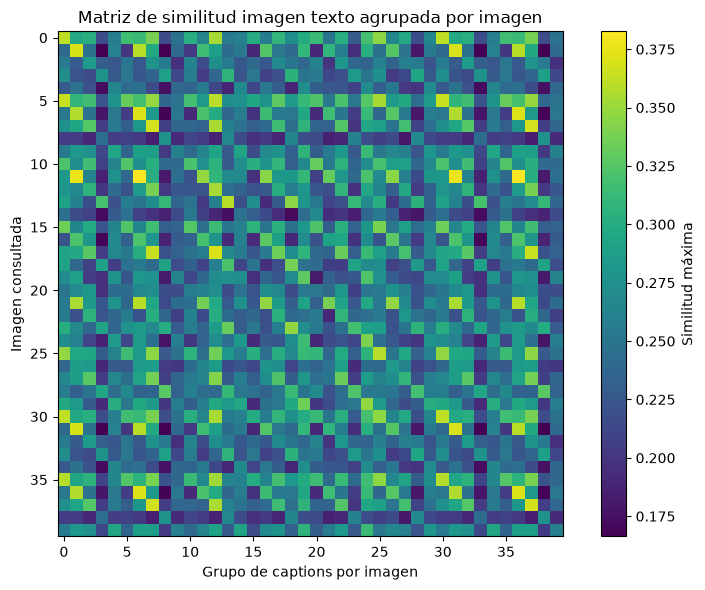

Figura guardada en: D:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-textiles-generados-evaluacion-multimodal\figures\matriz_similitud_agrupada.png


In [16]:
# ============================================================
# 15. Matriz de similitud imagen contra grupo de captions
# ============================================================

image_to_group_scores = []

for image_idx, image_id in enumerate(image_ids):
    row_scores = []

    for target_image_id in image_ids:
        text_indices = texts_df.index[texts_df["image_id"] == target_image_id].tolist()
        max_score = similarity_np[image_idx, text_indices].max()
        row_scores.append(max_score)

    image_to_group_scores.append(row_scores)

image_to_group_scores = np.array(image_to_group_scores)

plt.figure(figsize=(8, 6))
plt.imshow(image_to_group_scores)
plt.colorbar(label="Similitud máxima")
plt.title("Matriz de similitud imagen texto agrupada por imagen")
plt.xlabel("Grupo de captions por imagen")
plt.ylabel("Imagen consultada")
plt.tight_layout()

matrix_path = FIGURES_DIR / "matriz_similitud_agrupada.png"
plt.savefig(matrix_path, dpi=150)
plt.show()

print("Figura guardada en:", matrix_path)

In [17]:
# ============================================================
# 16. Resumen automático de resultados
# ============================================================

summary = {
    "modelo": f"OpenCLIP {MODEL_NAME}",
    "pretrained": PRETRAINED,
    "device": DEVICE,
    "numero_imagenes": int(len(manifest)),
    "numero_textos": int(len(texts_df)),
    "metricas_modelo": model_metrics,
    "metricas_baseline": baseline_metrics
}

summary_path = RESULTS_DIR / "resumen_evaluacion.json"

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

summary

{'modelo': 'OpenCLIP ViT-B-32',
 'pretrained': 'laion2b_s34b_b79k',
 'device': 'cpu',
 'numero_imagenes': 40,
 'numero_textos': 200,
 'metricas_modelo': {'Recall@1': 0.325,
  'Recall@5': 0.6,
  'Recall@10': 0.85,
  'MRR': 0.4812562240391188,
  'rank_promedio_correcto': 5.45},
 'metricas_baseline': {'Recall@1': 0.026175000000000004,
  'Recall@5': 0.1193,
  'Recall@10': 0.22542500000000001,
  'MRR': 0.09703543051711043,
  'rank_promedio_correcto': 33.8198}}

In [19]:
# ============================================================
# 17. Lectura del resumen guardado
# ============================================================

with open(summary_path, "r", encoding="utf-8") as f:
    loaded_summary = json.load(f)

print(json.dumps(loaded_summary, ensure_ascii=False, indent=2))

{
  "modelo": "OpenCLIP ViT-B-32",
  "pretrained": "laion2b_s34b_b79k",
  "device": "cpu",
  "numero_imagenes": 40,
  "numero_textos": 200,
  "metricas_modelo": {
    "Recall@1": 0.325,
    "Recall@5": 0.6,
    "Recall@10": 0.85,
    "MRR": 0.4812562240391188,
    "rank_promedio_correcto": 5.45
  },
  "metricas_baseline": {
    "Recall@1": 0.026175000000000004,
    "Recall@5": 0.1193,
    "Recall@10": 0.22542500000000001,
    "MRR": 0.09703543051711043,
    "rank_promedio_correcto": 33.8198
  }
}


In [20]:
# ============================================================
# 18. Revisión de métricas exportadas
# ============================================================

metrics_path = RESULTS_DIR / "metricas.csv"

metrics_df = pd.read_csv(metrics_path)

metrics_df

,experimento,modelo,direccion,numero_imagenes,numero_textos,metrica,resultado,interpretacion
0,E1,OpenCLIP ViT-B-32,imagen_texto,40,200,Recall@1,0.325000,Resultado del modelo en recuperación imagen texto
1,E1,OpenCLIP ViT-B-32,imagen_texto,40,200,Recall@5,0.600000,Resultado del modelo en recuperación imagen texto
2,E1,OpenCLIP ViT-B-32,imagen_texto,40,200,Recall@10,0.850000,Resultado del modelo en recuperación imagen texto
3,E1,OpenCLIP ViT-B-32,imagen_texto,40,200,MRR,0.481256,Resultado del modelo en recuperación imagen texto
4,E1,OpenCLIP ViT-B-32,imagen_texto,40,200,rank_promedio_correcto,5.450000,Resultado del modelo en recuperación imagen texto
5,E2,baseline_aleatorio,imagen_texto,40,200,Recall@1,0.026175,Resultado promedio de un ranking aleatorio
6,E2,baseline_aleatorio,imagen_texto,40,200,Recall@5,0.119300,Resultado promedio de un ranking aleatorio
7,E2,baseline_aleatorio,imagen_texto,40,200,Recall@10,0.225425,Resultado promedio de un ranking aleatorio
8,E2,baseline_aleatorio,imagen_texto,40,200,MRR,0.097035,Resultado promedio de un ranking aleatorio
9,E2,baseline_aleatorio,imagen_texto,40,200,rank_promedio_correcto,33.819800,Resultado promedio de un ranking aleatorio


In [21]:
# ============================================================
# 19. Tabla comparativa modelo versus baseline
# ============================================================

comparison_df = metrics_df.pivot_table(
    index="metrica",
    columns="modelo",
    values="resultado",
    aggfunc="first"
).reset_index()

comparison_df

modelo,metrica,OpenCLIP ViT-B-32,baseline_aleatorio
0,MRR,0.481256,0.097035
1,Recall@1,0.325000,0.026175
2,Recall@10,0.850000,0.225425
3,Recall@5,0.600000,0.119300
4,rank_promedio_correcto,5.450000,33.819800


In [22]:
# ============================================================
# 20. Exportación de tabla comparativa
# ============================================================

comparison_path = RESULTS_DIR / "comparacion_modelo_baseline.csv"
comparison_df.to_csv(comparison_path, index=False, encoding="utf-8")

print("Tabla comparativa exportada a:", comparison_path)
comparison_df

Tabla comparativa exportada a: D:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-textiles-generados-evaluacion-multimodal\results\comparacion_modelo_baseline.csv


modelo,metrica,OpenCLIP ViT-B-32,baseline_aleatorio
0,MRR,0.481256,0.097035
1,Recall@1,0.325000,0.026175
2,Recall@10,0.850000,0.225425
3,Recall@5,0.600000,0.119300
4,rank_promedio_correcto,5.450000,33.819800


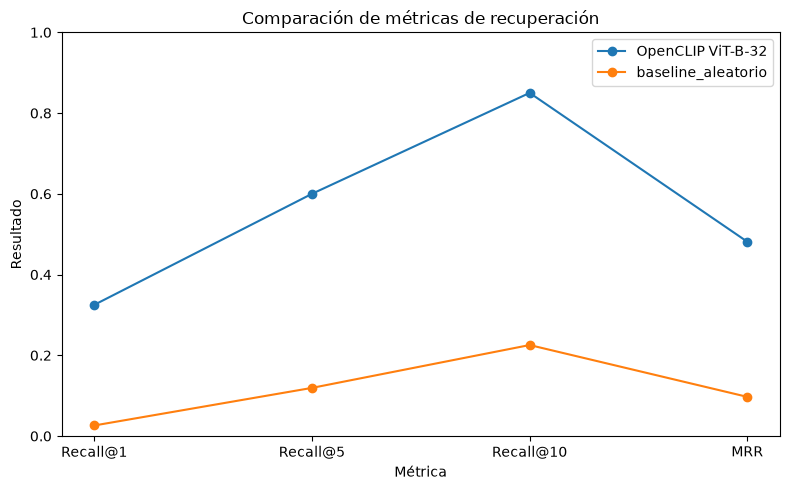

Figura guardada en: D:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-textiles-generados-evaluacion-multimodal\figures\comparacion_metricas.png


In [23]:
# ============================================================
# 21. Gráfico de métricas principales
# ============================================================

plot_metrics = ["Recall@1", "Recall@5", "Recall@10", "MRR"]

plot_df = metrics_df[metrics_df["metrica"].isin(plot_metrics)].copy()

plt.figure(figsize=(8, 5))

for modelo in plot_df["modelo"].unique():
    subset = plot_df[plot_df["modelo"] == modelo]
    plt.plot(subset["metrica"], subset["resultado"], marker="o", label=modelo)

plt.title("Comparación de métricas de recuperación")
plt.xlabel("Métrica")
plt.ylabel("Resultado")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

comparison_fig_path = FIGURES_DIR / "comparacion_metricas.png"
plt.savefig(comparison_fig_path, dpi=150)
plt.show()

print("Figura guardada en:", comparison_fig_path)

In [25]:
# ============================================================
# 22. Interpretación preliminar de resultados
# ============================================================

def get_metric_value(df, modelo_keyword, metric_name):
    subset = df[
        df["modelo"].str.contains(modelo_keyword, case=False, na=False)
        & (df["metrica"] == metric_name)
    ]

    if subset.empty:
        return None

    return float(subset.iloc[0]["resultado"])


model_recall1 = get_metric_value(metrics_df, "OpenCLIP", "Recall@1")
model_recall5 = get_metric_value(metrics_df, "OpenCLIP", "Recall@5")
model_mrr = get_metric_value(metrics_df, "OpenCLIP", "MRR")

baseline_recall1 = get_metric_value(metrics_df, "baseline", "Recall@1")
baseline_recall5 = get_metric_value(metrics_df, "baseline", "Recall@5")
baseline_mrr = get_metric_value(metrics_df, "baseline", "MRR")

print("Recall@1 modelo:", model_recall1)
print("Recall@5 modelo:", model_recall5)
print("MRR modelo:", model_mrr)
print("Recall@1 baseline:", baseline_recall1)
print("Recall@5 baseline:", baseline_recall5)
print("MRR baseline:", baseline_mrr)

if model_recall1 is not None and baseline_recall1 is not None:
    if model_recall1 > baseline_recall1:
        print("El modelo supera al baseline en Recall@1.")
    else:
        print("El modelo no supera claramente al baseline en Recall@1.")

if model_recall5 is not None and baseline_recall5 is not None:
    if model_recall5 > baseline_recall5:
        print("El modelo supera al baseline en Recall@5.")
    else:
        print("El modelo no supera claramente al baseline en Recall@5.")

Recall@1 modelo: 0.325
Recall@5 modelo: 0.6
MRR modelo: 0.4812562240391188
Recall@1 baseline: 0.026175
Recall@5 baseline: 0.1193
MRR baseline: 0.0970354305171104
El modelo supera al baseline en Recall@1.
El modelo supera al baseline en Recall@5.
